In [50]:
import os

from dotenv import load_dotenv

load_dotenv()

if os.environ["GROQ_API_KEY"]:
    print("GROQ_API_KEY is set")
else:
    raise ValueError("GROQ_API_KEY is not set")

GROQ_API_KEY is set


In [44]:
# from langchain_google_genai import ChatGoogleGenerativeAI

# model = ChatGoogleGenerativeAI(
#     model="gemini-3.6-flash",
#     temperature=1.0,  # Gemini 3.0+ defaults to 1.0
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
#     # other params...
# )

In [55]:
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

response = llm.invoke([
    HumanMessage(
        content="what is the temp in la"
    )]
)

response.content[0]["text"]

NotFoundError: Error code: 404 - {'error': {'message': 'The model `qwen/qwen3-32b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [46]:
from typing import TypedDict , List,Annotated
from operator import add

class graph_Schema(TypedDict):

    # message_mannual: List

    # using reducer in langraph
    message_auto: Annotated[List,add]




In [47]:
from langchain_core.messages import AIMessage , HumanMessage

def create_post(state: graph_Schema)->graph_Schema:


    # message_mannual=state["message_mannual"]

    # response_mannual = model.invoke(message_mannual).content[0]["text"]

    # response_mannual_ai = AIMessage(content=response_mannual)

    # state["message_mannual"] = message_mannual + [response_mannual_ai]



    message_auto = state["message_auto"]
    response_auto = model.invoke(message_auto).content[0]["text"]
    response_auto_ai = AIMessage(content=response_auto)

    state["message_auto"] = [response_auto_ai]
    return state

    





def currate_post(state: graph_Schema)->graph_Schema:




    # message_mannual = state["message_mannual"]

    # response_mannual = model.invoke(message_mannual).content[0]["text"]

    # response_mannual_ai = AIMessage(content=response_mannual)

    # state["message_mannual"] = message_mannual + [response_mannual_ai]
    message_auto = state["message_auto"]
    response_auto = model.invoke(message_auto).content[0]["text"]
    response_auto_ai = AIMessage(content=response_auto)
    
    state["message_auto"] = [response_auto_ai]
    


    return state





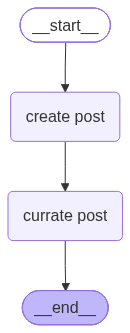

In [48]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(
    graph_Schema)

graph.add_node("create post",create_post)
graph.add_node("currate post",currate_post)

graph.add_edge(START,"create post")
graph.add_edge("create post","currate post")
graph.add_edge("currate post",END)


messages_graph = graph.compile()

from IPython.display import display,Image

#you could see the error with the below command
Image(messages_graph.get_graph().draw_mermaid_png())

In [49]:
messages_graph.invoke(
    {'message_auto':[
        HumanMessage(content="what is the gdp of india"),]
    }
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.7-flash' (INVALID_ARGUMENT): 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Requests ending with a model turn are not supported.', 'status': 'INVALID_ARGUMENT'}}